## makemore: part 3

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
# Read all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [5]:
len(words)

32033

In [6]:
# build vocabulary of characters and mappings to/from integers
chars = ['.'] + sorted(list(set(''.join(words))))
stoi = {s: i for i, s in enumerate(chars)}
vocab_size = len(chars)
print(vocab_size)

27


In [7]:
# build the dataset
block_size = 3          # context length: how many chars to use to predict the next one

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]    # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr    = build_dataset(words[:n1])         # 80%
Xdev, Ydev  = build_dataset(words[n1:n2])       # 10%
Xte, Yte    = build_dataset(words[n2:])         # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
# MLP revisited
n_embd = 10         # dimensionality of the character embedding vectors
n_hidden = 200      # the number of neurons in the hidden layer

g = torch.Generator().manual_seed(42)       # for reproducibility
C = torch.randn((vocab_size, n_embd),               generator=g)
W1 = torch.randn((n_hidden, block_size * n_embd),   generator=g) * 0.2
b1 = torch.randn(n_hidden,                          generator=g) * 0.01
W2 = torch.randn((vocab_size, n_hidden),            generator=g) * 0.01
b2 = torch.randn(vocab_size,                        generator=g) * 0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(f'Total params: {sum(p.nelement() for p in parameters)}')
for p in parameters:
    p.requires_grad = True

Total params: 12297


In [7]:
# Expected loss at initialization
# If the model were to predict characters uniformly randomly, we would expect a probability of 1/27 to be assigned to the target character each time.
# The avg negative log likelihood in that case would be
-torch.tensor(1/27).log()

tensor(3.2958)

In [8]:
# Same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # construct minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb]
    embcat = emb.view((-1, block_size * n_embd))
    h_preact = embcat @ W1.T + b1                   # hidden layer pre-activation
    h_preact = (h_preact - h_preact.mean(0, keepdim=True)) / h_preact.std(0, keepdim=True)  # Batch-norm: notice that we calculate mean and std over all the examples in a batch - a specific dimension
    h_preact = bngain * h_preact + bnbias           # scale and shift batch-norm output
    h = torch.tanh(h_preact)
    logits = h @ W2.T + b2
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 50000 else (0.01 if i < 100000 else 0.0001)
    for p in parameters:
        p.data += lr * (-p.grad)
    
    # track
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.item())
    # break                                         # un-comment to stop after 1st step - useful if you wanna examine the network at initialization

      0/ 200000: 3.3209
  10000/ 200000: 2.3183
  20000/ 200000: 2.4184
  30000/ 200000: 2.3237
  40000/ 200000: 2.1923
  50000/ 200000: 1.8352
  60000/ 200000: 2.0245
  70000/ 200000: 2.3761
  80000/ 200000: 2.1763
  90000/ 200000: 1.9536
 100000/ 200000: 2.0932
 110000/ 200000: 2.1709
 120000/ 200000: 1.9062
 130000/ 200000: 2.0800
 140000/ 200000: 1.9062
 150000/ 200000: 2.1108
 160000/ 200000: 2.1748
 170000/ 200000: 1.9304
 180000/ 200000: 2.3482
 190000/ 200000: 2.0505


### Examining initialization

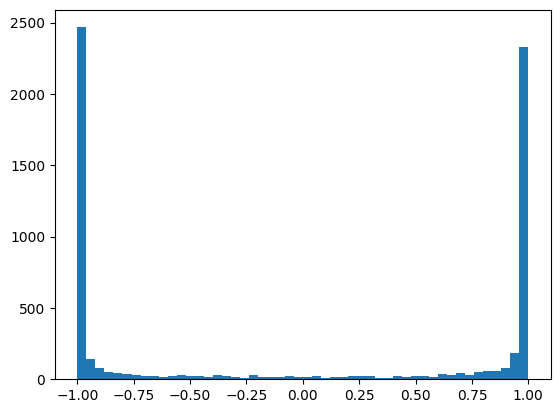

In [ ]:
# Plotting hidden layer activations right after the first step or at initialization
plt.hist(h.view(-1).tolist(), 50);

^ Lots of dead outputs (backpropagated grad for all the neurons that output ~(-1) or ~1 will be 0 - see how we calculate grad for tanh in micrograd) - gradient vanishes

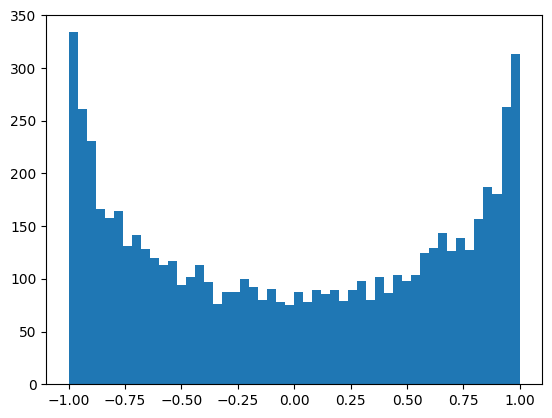

In [49]:
# (after fixes)
plt.hist(h.view(-1).tolist(), 50);

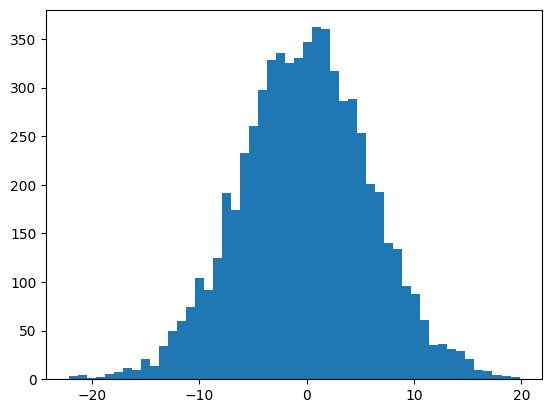

In [43]:
plt.hist(h_preact.view(-1).tolist(), 50);

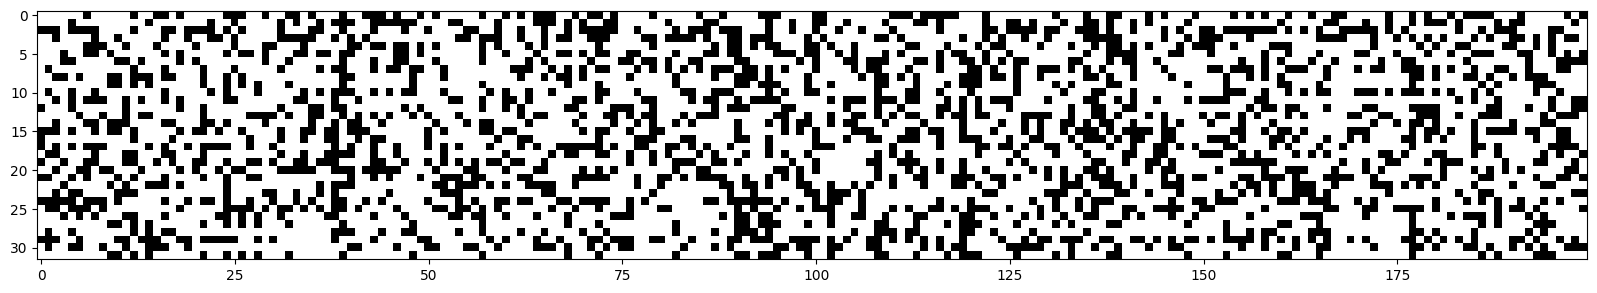

In [ ]:
# (before fixes)
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

^If the activations from a neuron were extreme (white) for all 32 inputs in a batch, a whole column would be white. For this neuron, it would mean that it would learn from none of the inputs from the mini-batch. That would be a "**dead neuron**" and we want to do our best to avoid the situation. Thankfully, none of the neurons are dead at least for the initial batch.

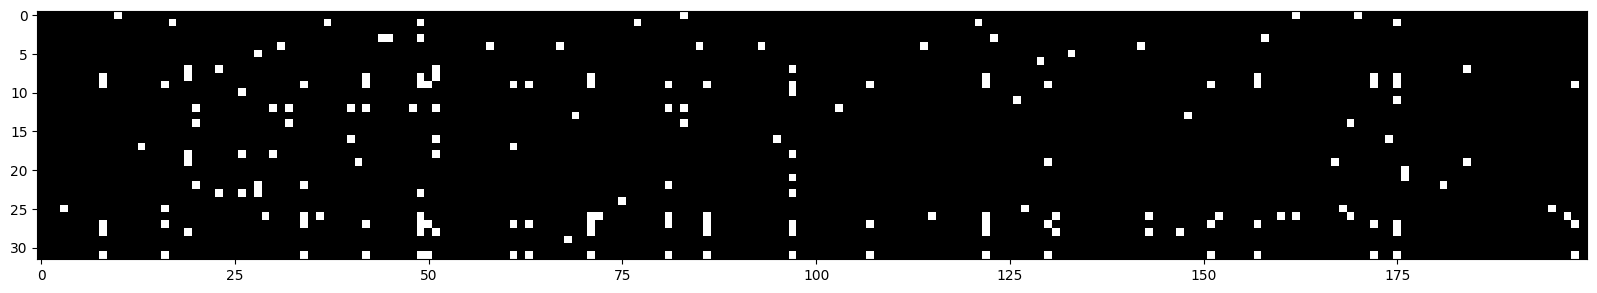

In [50]:
# (after fixes)
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

### Training results

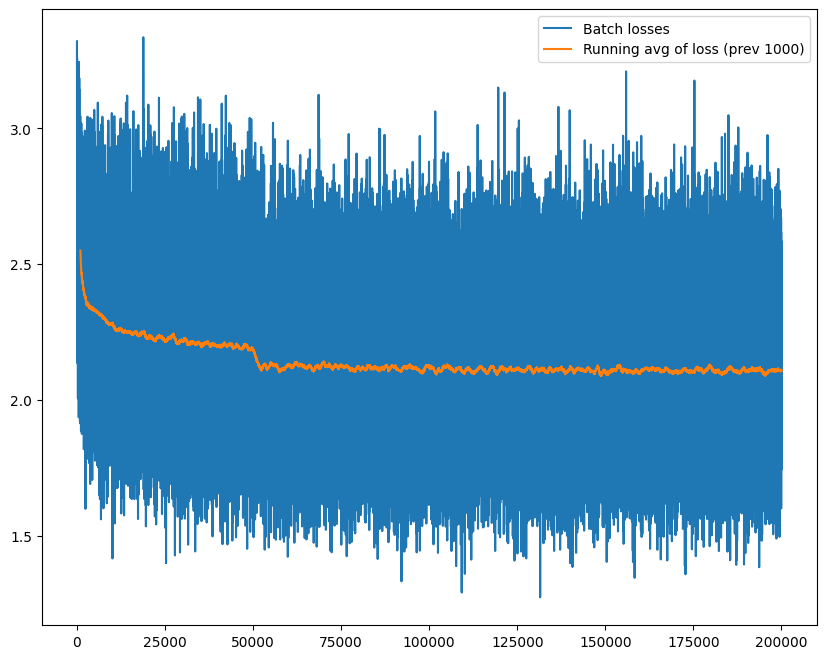

In [9]:
plt.figure(figsize=(10, 8))
plt.plot(lossi, label="Batch losses")

ix = torch.arange(1000, max_steps)
prev1000avg = [sum(lossi[i - 1000: i]) / 1000 for i in ix]
plt.plot(ix, prev1000avg, label="Running avg of loss (prev 1000)")
plt.legend();

In [ ]:
# calibrate batch norm at the end of training
with torch.no_grad():
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    h_preact = embcat @ W1.T + b1

    # measure mean/std over the entire training set forward pass
    bnmean = h_preact.mean(0, keepdim=True)
    bnstd = h_preact.std(0, keepdim=True)

In [11]:
# Print train and validation loss
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]
    emb = C[x]
    embcat = emb.view((-1, block_size * n_embd))
    h_preact = embcat @ W1.T + b1
    h_preact = bngain * (h_preact - bnmean) / bnstd + bnbias    # use calibrated mean and bias over training set for inference
    h = torch.tanh(h_preact)
    logits = h @ W2.T + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.081141471862793
val 2.1196396350860596


In [13]:
# Sample from trained model
max_iters = 20
num_generations = 20

for _ in range(num_generations):
    generation = '.'
    context = [0] * block_size
    for _ in range(max_iters):
        # Get embeddings
        emb = C[context]        # (block_size, embedding_size)

        # Forward pass
        logits = torch.tanh(emb.view(-1, block_size * n_embd) @ W1.T + b1) @ W2.T + b2  # (1, 27)
        probs = F.softmax(logits, 1)
        
        # Sample according to probabilities and update context
        ix = torch.multinomial(probs, 1, replacement=True, generator=g).item()
        generation += chars[ix]
        context = context[1:] + [ix]

        if ix == 0:
            break
    
    print(generation)

.jaddalt.
.frus.
.braxtzy.
.dakmiry.
.dnvushtvahnda.
.vius.
.flnikirannav.
.fferdon.
.clarkelydzke.
.sthfizkydrup.
.westya.
.dav.
.fanryd.
.kenli.
.litlynkviah.
.gwsirsebamner.
.khygranza.
.jullhatlabdun.
.corda.
.gwrmbentlan.


### Pytorchifying the Code

In [11]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn(fan_in, fan_out) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True

        # Parameters (to be trained)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        # Buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.zeros(dim)
    
    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)                 # batch mean
            xvar  = x.var(0, keepdim=True, unbiased=True)   # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)    # normalize to unit variance
        self.out = self.gamma * xhat + self.beta

        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

In [35]:
# Network definition
n_embd = 10
n_hidden = 100
g = torch.Generator().manual_seed(432)

C = torch.randn((vocab_size, n_embd))
layers = [
    Linear(n_embd * block_size, n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), Tanh(),
    Linear(           n_hidden, vocab_size),
]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].weight *= 0.1

    # apply gain for all other layers
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


46497


In [36]:
# Training loop
max_steps = 100000
batch_size = 64
lossi = []
ud = []         # tracks update: data ratio

for i in range(max_steps):
    # construct minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)  # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()     # What does this mean?
    
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1  if i < 50000 else 0.01
    for p in parameters:
        p.data += lr * (-p.grad)
    
    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])      # why std instead of abs?

    if i >= 1000:
        break   # Take out to run full optimization

      0/ 100000: 3.2989


#### Visualizing activation statistics

layer 1 (      Tanh): mean +0.00, std 0.76, saturated: 20.70%
layer 3 (      Tanh): mean -0.01, std 0.71, saturated: 10.86%
layer 5 (      Tanh): mean +0.01, std 0.71, saturated: 9.56%
layer 7 (      Tanh): mean +0.02, std 0.71, saturated: 8.98%
layer 9 (      Tanh): mean +0.01, std 0.72, saturated: 10.12%


Text(0.5, 1.0, 'activation distribution')

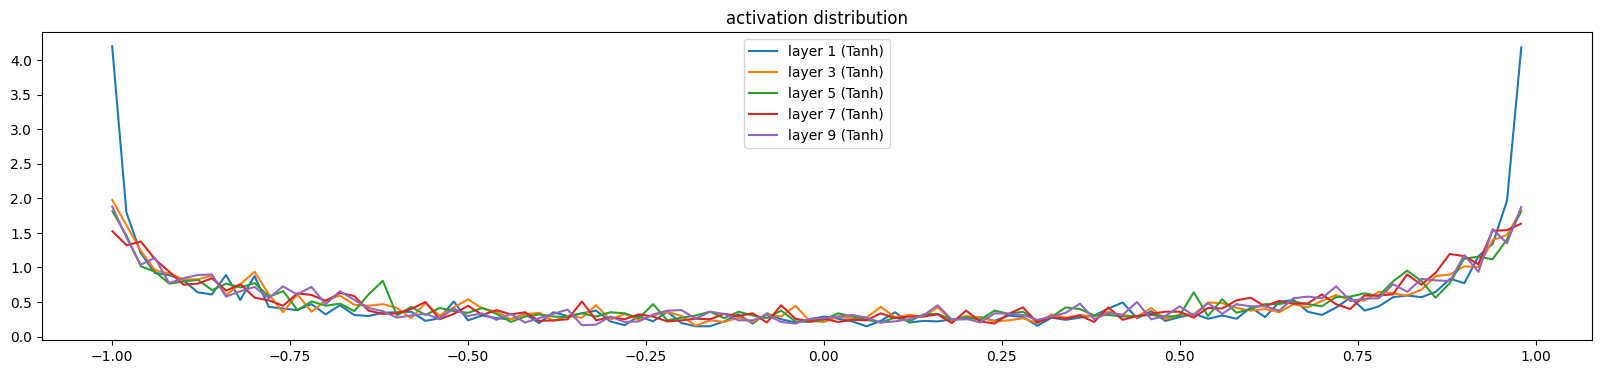

In [40]:
# visualize activations - forward pass
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]): # excluding output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).sum() * 100 / t.nelement()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('activation distribution')

layer 1 (      Tanh): mean +0.00, std 0.00
layer 3 (      Tanh): mean -0.00, std 0.00
layer 5 (      Tanh): mean -0.00, std 0.00
layer 7 (      Tanh): mean +0.00, std 0.00
layer 9 (      Tanh): mean -0.00, std 0.00


Text(0.5, 1.0, 'output gradient distribution')

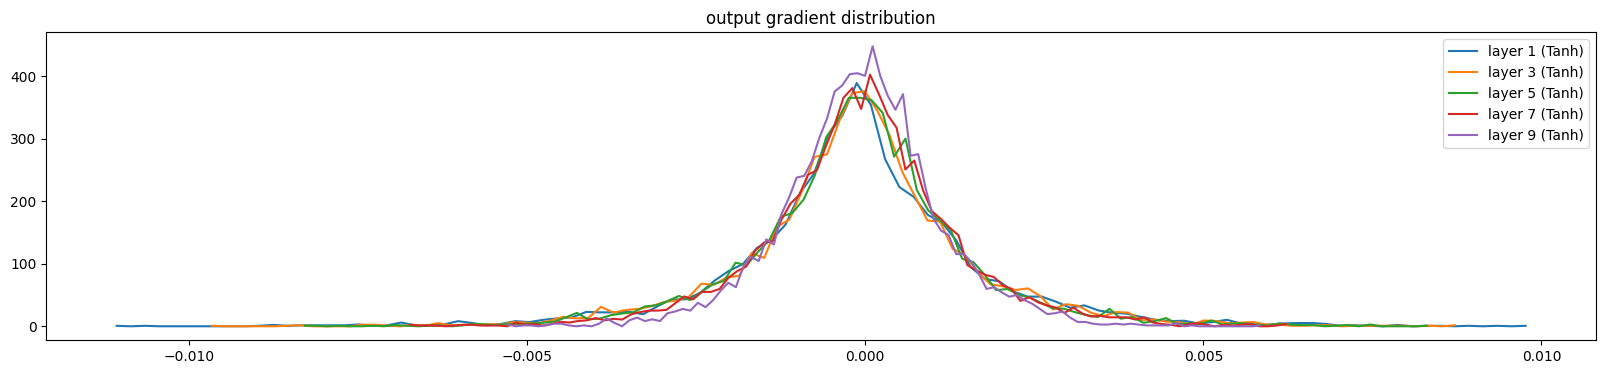

In [41]:
# visualize gradients - backward pass
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]): # excluding output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad              # Notice that it's layer output's grad rather layer parameters' grad
        print('layer %d (%10s): mean %+.2f, std %.2f' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('output gradient distribution')

weight   (27, 10) | mean -0.000293 | std 9.392970e-03 | grad:data ratio 7.199202e-03
weight  (30, 100) | mean -0.000317 | std 8.854717e-03 | grad:data ratio 2.768909e-02
weight (100, 100) | mean -0.000005 | std 6.600237e-03 | grad:data ratio 3.850593e-02
weight (100, 100) | mean +0.000015 | std 5.537642e-03 | grad:data ratio 3.193905e-02
weight (100, 100) | mean -0.000079 | std 4.730791e-03 | grad:data ratio 2.674711e-02
weight (100, 100) | mean -0.000062 | std 3.709770e-03 | grad:data ratio 2.124289e-02
weight  (100, 27) | mean -0.000000 | std 1.433825e-02 | grad:data ratio 1.937293e-01


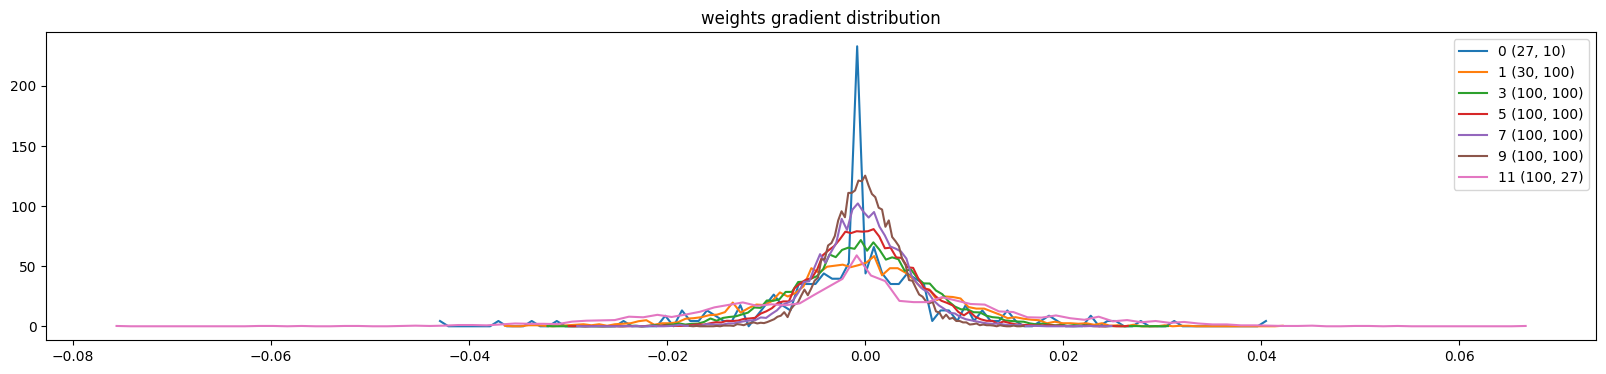

In [42]:
plt.figure(figsize=(20, 4))
legends = []

for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.abs().mean() / p.data.abs().mean()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

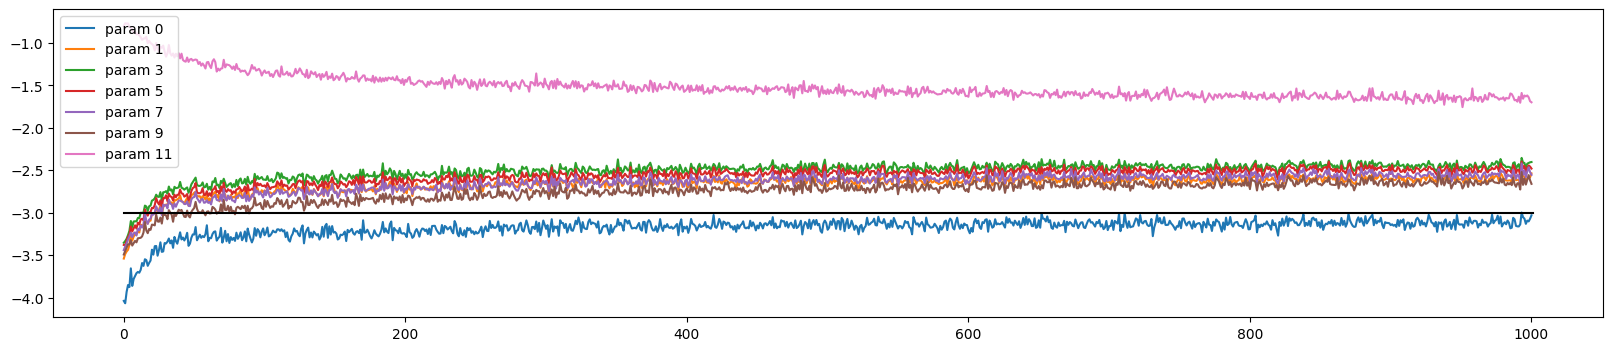

In [ ]:
# visualize update/data ratio over training
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k')   # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [19]:
# Evaluation
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, y)
    print(split, loss.item())

# put layers into eval mode
for layer in layers:
    layer.training = False

split_loss('train')
split_loss('val')

train 3.258810520172119
val 3.2578864097595215


In [28]:
# Sample from trained model
max_iters = 20
num_generations = 20

for _ in range(num_generations):
    generation = '.'
    context = [0] * block_size
    for _ in range(max_iters):
        # Get embeddings
        emb = C[context]        # (block_size, embedding_size)
        emb = emb.unsqueeze(0)  # (1, block_size, embedding_size)

        # Forward pass
        x = emb.view(emb.shape[0], -1)
        for layer in layers:
            x = layer(x)
        probs = F.softmax(x, 1)
        
        # Sample according to probabilities and update context
        ix = torch.multinomial(probs, 1, replacement=True, generator=g).item()
        generation += chars[ix]
        context = context[1:] + [ix]

        if ix == 0:
            break
    
    print(generation)

.xiriszumqewsysjjwuc.
.csphtsqay.
.nhae.
.vsqyqnmmtollwgznsdtm
.hvaymlbwaixqcmeahmqz
.noinrlcpsix.
.nprs.
.osouddfaipibzg.
.yoxlucothctcgbnatntu
.uqoeznqu.
.nbaolgyydrevauxvpqfg
.lkmvnnnsq.
.qjioyobccitkqzlduspu
.qu.
.qafthvujlepkpjbsmwdc
.ocybtdteisgvcqombpwg
.xsgqsudktneb.
.kqtvrpiipksbnfwgulyf
.tqjgpizxujalpra.
.wrhuiiyrhasahhqckjfs
